In [29]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [30]:
!pip install -q kagglehub

import kagglehub
import os

# Download dataset from Kaggle
dataset_path = kagglehub.dataset_download(
    "farzadnekouei/trash-type-image-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

print("\nFiles/folders:")
print(os.listdir(dataset_path))

Dataset downloaded to:
/root/.cache/kagglehub/datasets/farzadnekouei/trash-type-image-dataset/versions/1

Files/folders:
['TrashType_Image_Dataset']


In [31]:
import os

print("Dataset path:")
print(dataset_path)

print("\nContents:")
print(os.listdir(dataset_path))

dataset_path = os.path.join(dataset_path, "TrashType_Image_Dataset")
print(os.listdir(dataset_path))

Dataset path:
/root/.cache/kagglehub/datasets/farzadnekouei/trash-type-image-dataset/versions/1

Contents:
['TrashType_Image_Dataset']
['trash', 'paper', 'glass', 'metal', 'cardboard', 'plastic']


In [32]:
import os
import matplotlib.pyplot as plt
class_counts = {}
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        class_counts[class_name] = len(images)
print(class_counts)

{'trash': 137, 'paper': 594, 'glass': 501, 'metal': 410, 'cardboard': 403, 'plastic': 482}


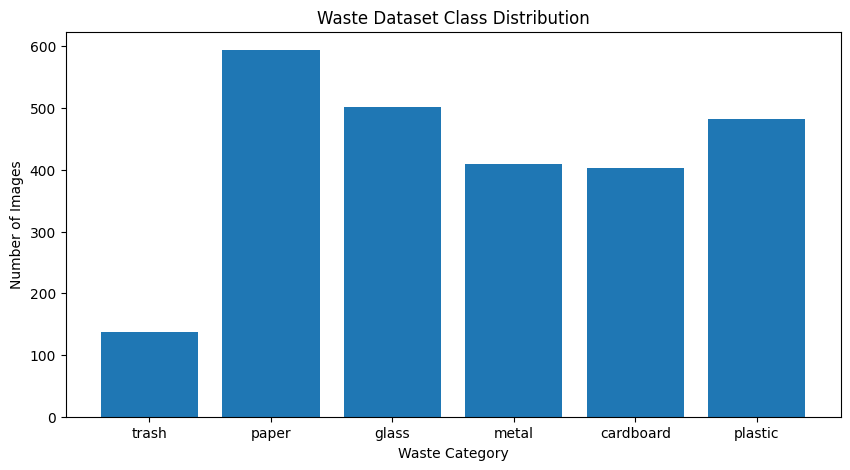

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.title("Waste Dataset Class Distribution")
plt.show()

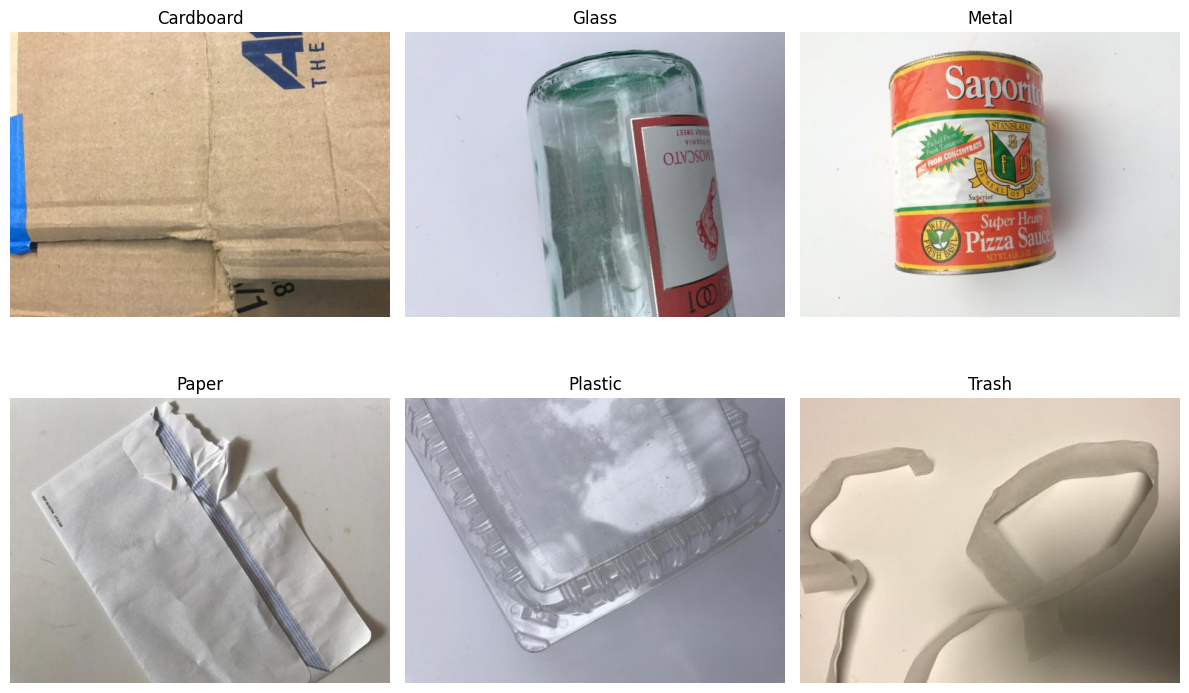

In [34]:
from PIL import Image
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
plt.figure(figsize=(12, 8))
for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    image_name = images[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name.capitalize())
    plt.axis('off')
    
plt.tight_layout()
plt.show()

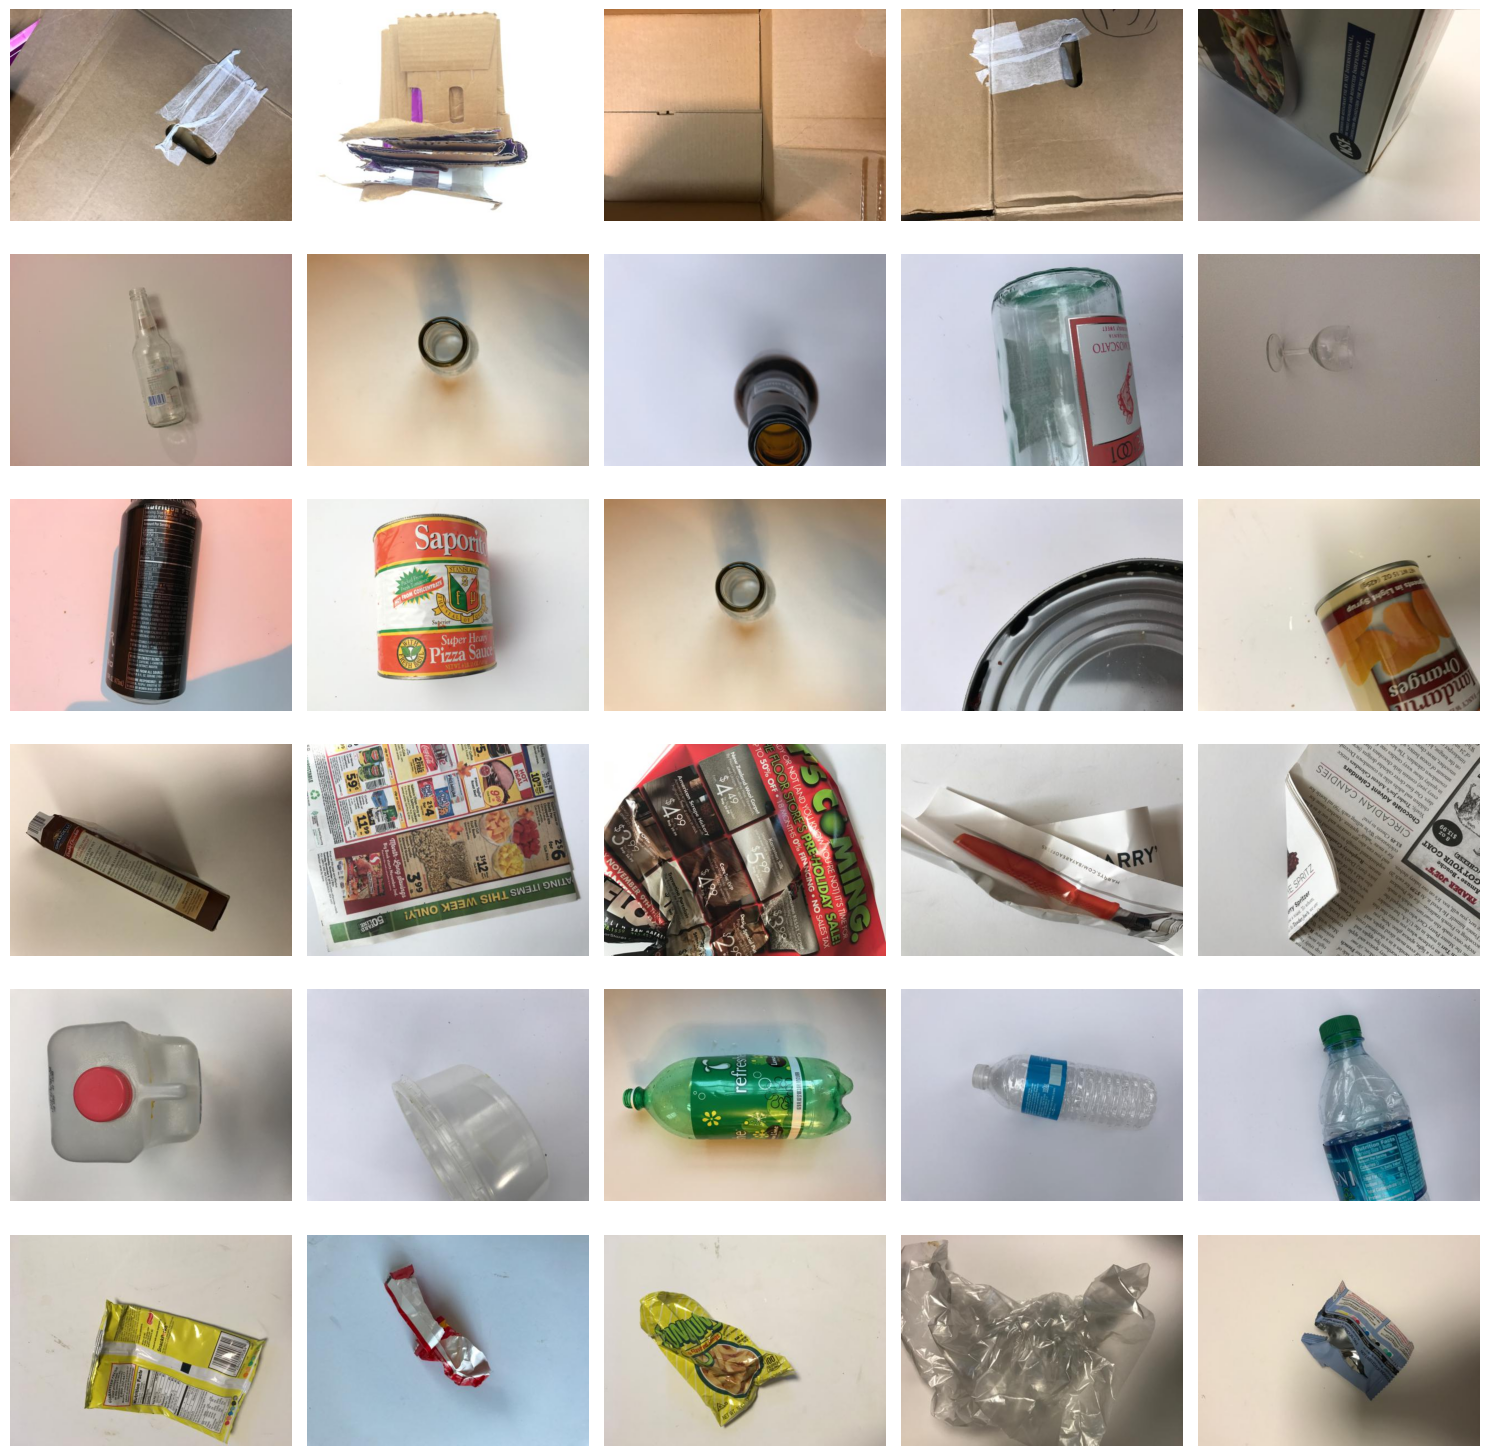

In [35]:
import random

plt.figure(figsize=(15, 15))

for row, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    selected_images = random.sample(images, min(5, len(images)))

    for col, image_name in enumerate(selected_images):

        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)

        position = row * 5 + col + 1

        plt.subplot(6, 5, position)
        plt.imshow(image)
        plt.axis('off')

        if col == 0:
            plt.ylabel(class_name.capitalize(), fontsize=12)

plt.tight_layout()
plt.show()

In [36]:
from PIL import Image
import os

widths = []
heights = []

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    for image_name in images:

        image_path = os.path.join(class_path, image_name)

        try:
            image = Image.open(image_path)

            widths.append(image.width)
            heights.append(image.height)

        except Exception as e:
            print("Error reading:", image_path)

print("Number of images:", len(widths))

print("Minimum width :", min(widths))
print("Maximum width :", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

Number of images: 2527
Minimum width : 512
Maximum width : 512
Minimum height: 384
Maximum height: 384


In [37]:
image_modes = {}

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    for image_name in images:

        image_path = os.path.join(class_path, image_name)

        try:
            image = Image.open(image_path)

            mode = image.mode

            image_modes[mode] = image_modes.get(mode, 0) + 1

        except:
            pass

print(image_modes)

{'RGB': 2527}


In [38]:
import os
import pandas as pd

data = []

classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):

        if image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(class_path, image_name)

            data.append({
                'filepath': image_path,
                'label': class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
df.head()

Total images: 2527


,filepath,label
0,/root/.cache/kagglehub/datasets/farzadnekouei/...,cardboard
1,/root/.cache/kagglehub/datasets/farzadnekouei/...,cardboard
2,/root/.cache/kagglehub/datasets/farzadnekouei/...,cardboard
3,/root/.cache/kagglehub/datasets/farzadnekouei/...,cardboard
4,/root/.cache/kagglehub/datasets/farzadnekouei/...,cardboard


In [39]:
print(df['label'].value_counts())

label
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

print("Training images:", len(train_df))
print("Temporary images:", len(temp_df))

Training images: 1768
Temporary images: 759


In [41]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 1768
Validation: 379
Testing: 380


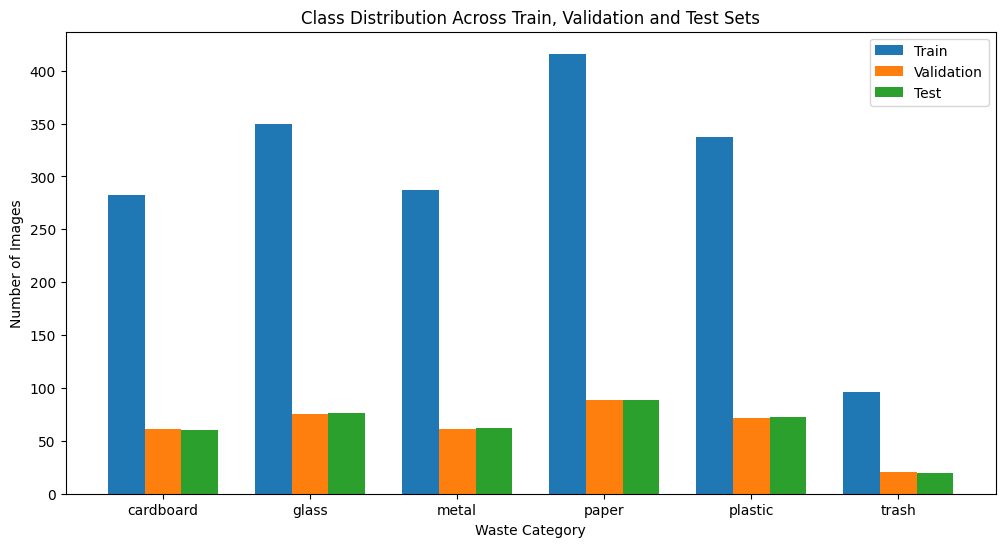

In [42]:
import matplotlib.pyplot as plt

train_counts = train_df['label'].value_counts().reindex(classes)
val_counts = val_df['label'].value_counts().reindex(classes)
test_counts = test_df['label'].value_counts().reindex(classes)

x = range(len(classes))

plt.figure(figsize=(12, 6))

plt.bar(
    [i - 0.25 for i in x],
    train_counts,
    width=0.25,
    label='Train'
)

plt.bar(
    x,
    val_counts,
    width=0.25,
    label='Validation'
)

plt.bar(
    [i + 0.25 for i in x],
    test_counts,
    width=0.25,
    label='Test'
)

plt.xticks(list(x), classes)
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Train, Validation and Test Sets")

plt.legend()
plt.show()

In [43]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

label_to_index = {
    class_name: i for i, class_name in enumerate(class_names)
}

print(label_to_index)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [44]:
def load_image(filepath, label):

    image = tf.io.read_file(filepath)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [45]:
def prepare_dataframe(dataframe):

    filepaths = dataframe['filepath'].values

    labels = [
        label_to_index[label]
        for label in dataframe['label']
    ]

    return filepaths, labels

In [46]:
train_files, train_labels = prepare_dataframe(train_df)
val_files, val_labels = prepare_dataframe(val_df)
test_files, test_labels = prepare_dataframe(test_df)

In [47]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_files, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_files, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_files, test_labels)
)

In [48]:
train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [49]:
train_ds = train_ds.shuffle(
    buffer_size=len(train_df),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)


In [50]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel minimum:", tf.reduce_min(images).numpy())
print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 1.0


In [51]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),
    layers.RandomContrast(0.10)
], name="data_augmentation")

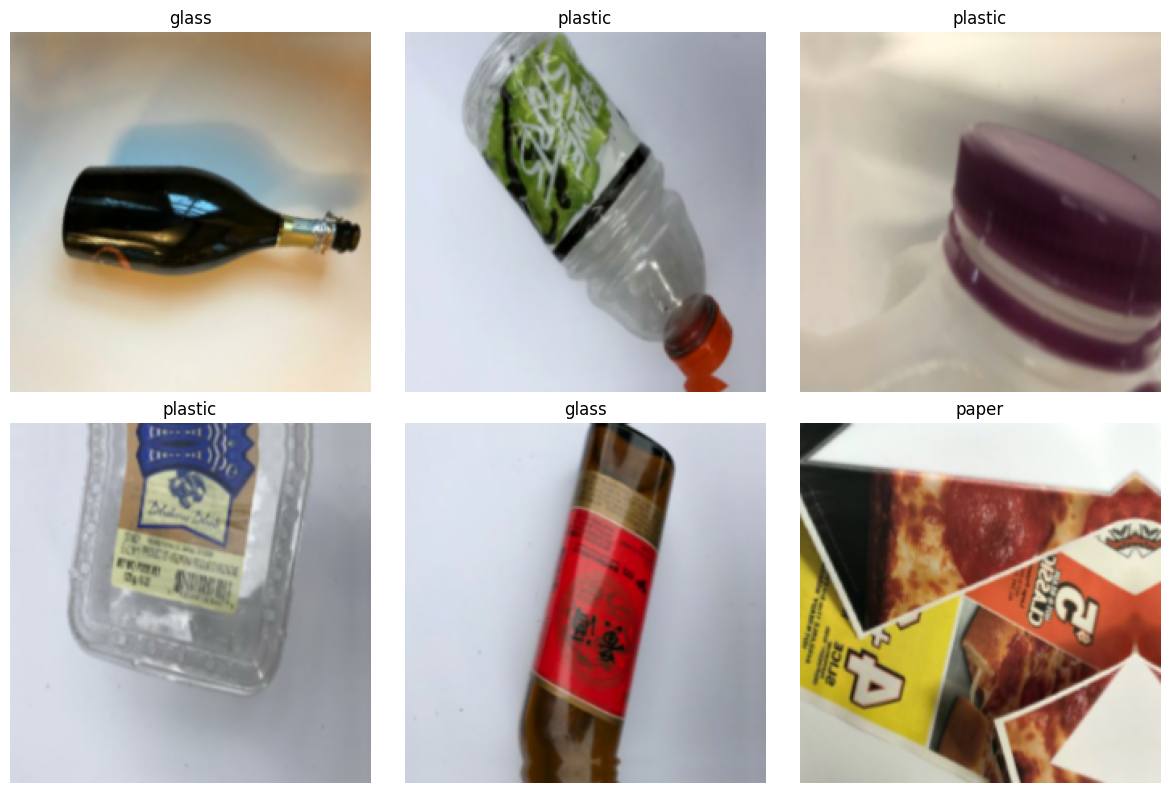

In [52]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(6):

    augmented_image = data_augmentation(
        images[i:i+1],
        training=True
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image[0])
    plt.title(classes[labels[i].numpy()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [53]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet169, DenseNet201
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

IMG_SHAPE = (224, 224, 3) # DenseNet's default input size
NUM_CLASSES = 6
base_model = DenseNet169(
    input_shape=IMG_SHAPE,
    include_top=False,     # Drops the original 1000-class ImageNet output layer
    weights='imagenet'     # Loads the pre-trained weights
)
base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)


# model = models.Sequential([
    
#     # Data augmentation
#     data_augmentation,

#     # Block 1
#     layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D((2, 2)),

#     # Block 2
#     layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D((2, 2)),

#     # Block 3
#     layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
#     layers.MaxPooling2D((2, 2)),

#     # Classification
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.50),


#     # 6 classes
#     layers.Dense(6, activation='softmax')
# ])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 12,652,870 (48.27 MB)

 Trainable params: 9,990 (39.02 KB)

 Non-trainable params: 12,642,880 (48.23 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),





    
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [56]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(6),
    y=train_labels
)

class_weights = {
    i: weight
    for i, weight in enumerate(class_weights_array)
}

print(class_weights)

{0: np.float64(1.044917257683215), 1: np.float64(0.8419047619047619), 2: np.float64(1.0267131242740999), 3: np.float64(0.7083333333333334), 4: np.float64(0.874381800197824), 5: np.float64(3.0694444444444446)}


In [57]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=34,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/34
56/56 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.5028 - loss: 1.3235 - val_accuracy: 0.7071 - val_loss: 0.8044 - learning_rate: 0.0010
Epoch 2/34
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 132ms/step - accuracy: 0.7008 - loss: 0.8394 - val_accuracy: 0.7361 - val_loss: 0.7065 - learning_rate: 0.0010
Epoch 3/34
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - accuracy: 0.7602 - loss: 0.6837 - val_accuracy: 0.7889 - val_loss: 0.6084 - learning_rate: 0.0010
Epoch 4/34
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - accuracy: 0.7805 - loss: 0.6033 - val_accuracy: 0.7863 - val_loss: 0.5977 - learning_rate: 0.0010
Epoch 5/34
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.8105 - loss: 0.5430 - val_accuracy: 0.7942 - val_loss: 0.5638 - learning_rate: 0.0010
Epoch 6/34
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.8269 - loss: 0.4817 - val_accuracy: 0.8232 - val_loss: 0.5328 - learning_rate: 0.0010
Epoch 7/34
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.8411 - loss: 0.4625

In [58]:
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])
best_train_acc = max(history.history['accuracy'])

print("Best Training Accuracy :", best_train_acc)
print("Best Validation Accuracy:", best_val_acc)
print("Best Validation Loss    :", best_val_loss)

Best Training Accuracy : 0.918552041053772
Best Validation Accuracy: 0.8469656705856323
Best Validation Loss    : 0.4471662938594818


In [59]:
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print("Best Validation Accuracy occurred at Epoch:", best_epoch)

Best Validation Accuracy occurred at Epoch: 20


In [60]:
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)
y_true = np.concatenate([y for x, y in val_ds], axis=0)
if len(y_true.shape) > 1 and y_true.shape[1] > 1:
    y_true = np.argmax(y_true, axis=1)

12/12 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step 


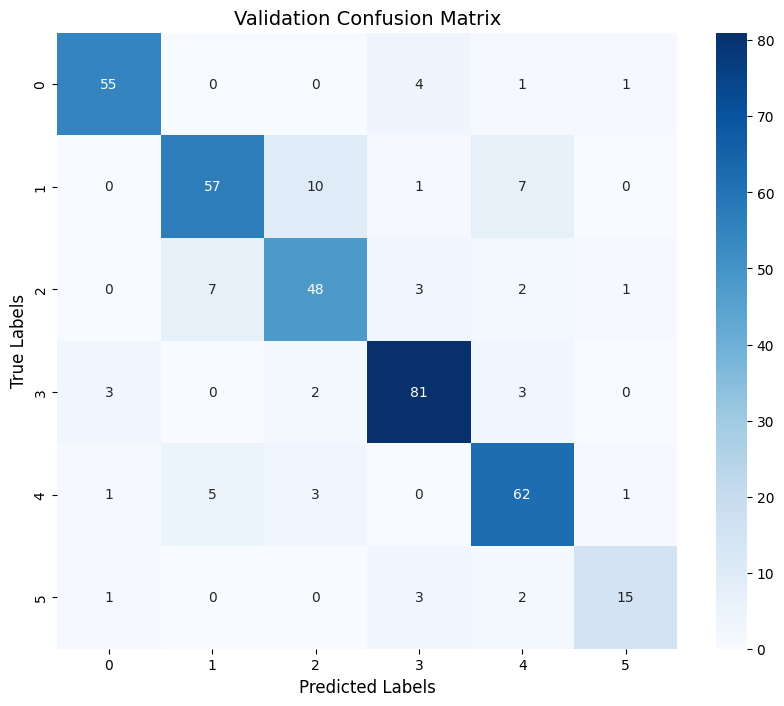

In [61]:
# 3. Compute the confusion matrix
cm = tf.math.confusion_matrix(labels=y_true, predictions=y_pred)

# 4. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues'
)

plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)
plt.title('Validation Confusion Matrix', fontsize=14)
plt.show()

In [62]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8447 - loss: 0.4568
Test Loss: 0.45682743191719055
Test Accuracy: 0.8447368144989014


In [63]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.91      0.88      0.90        60
       glass       0.83      0.84      0.84        76
       metal       0.84      0.84      0.84        62
       paper       0.85      0.92      0.88        89
     plastic       0.87      0.75      0.81        73
       trash       0.65      0.75      0.70        20

    accuracy                           0.84       380
   macro avg       0.83      0.83      0.83       380
weighted avg       0.85      0.84      0.84       380



In [64]:
model.save("waste_classifier_densenet201.keras")

In [65]:
import os
print(os.listdir("/content"))

['.config', 'waste_classifier_densenet201.keras', 'Trash2.jpeg', 'sample_data']


In [66]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "/content/waste_classifier_densenet201.keras"
)

print("✅ Model loaded!")

✅ Model loaded!


In [67]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

image_path = "/content/Trash2.jpeg"

# Load image
img = Image.open(image_path).convert("RGB")

# Resize
img_resized = img.resize((224, 224))

# Convert to array
img_array = np.array(img_resized)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array, verbose=0)[0]

# Get predicted class
predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]
confidence = predictions[predicted_index] * 100

print("Prediction:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

Prediction: cardboard
Confidence: 94.91%


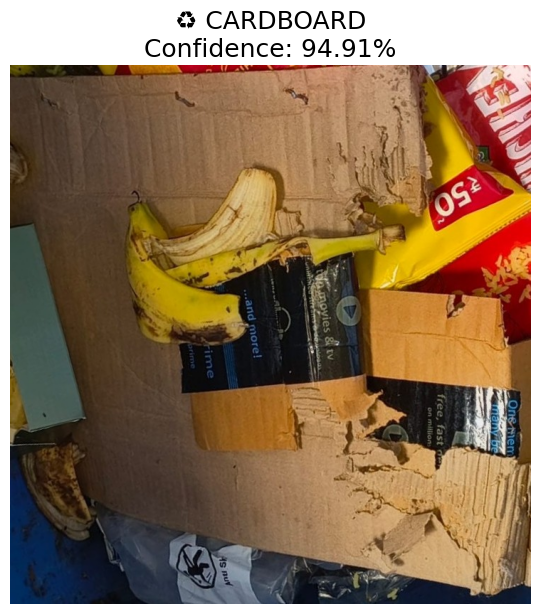

In [68]:
plt.figure(figsize=(7, 7))

plt.imshow(img)
plt.axis("off")

plt.title(
    f"♻️ {predicted_class.upper()}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=18
)

plt.show()

In [69]:
print("\nClass probabilities:")

for name, probability in zip(class_names, predictions):
    print(f"{name:10s}: {probability * 100:.2f}%")
    


Class probabilities:
cardboard : 94.91%
glass     : 0.00%
metal     : 0.04%
paper     : 4.98%
plastic   : 0.03%
trash     : 0.05%
